In [2]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

In [12]:
read.table("/home/user/data3/rbase/small_peptide/denovo_genes/denovo_genes.no_paralog.tsv",header = T) -> denovo_genes
head(denovo_genes)

,orf_id,lineage,orig_age,syn_age
,<chr>,<chr>,<chr>,<chr>
1,PB.111.1_chr1_-_244_4307_2825_3008_dORF_ATG,hominoid,primatomorpha,placentalia
2,PB.1115.29_chr1___125_3560_2418_2475_noncoding_GTG,hominoid,primates,placentalia
3,PB.1122.58_chr1_-_4_1526_102_132_noncoding_ACG,hominoid,hominoid,placentalia
4,PB.1203.3_chr1_-_270_4237_3164_3371_dORF_ATG,hominoid,hominoid,placentalia
5,PB.1210.15_chr1_-_117_2897_1744_1816_noncoding_CTG,hominoid,placentalia,mammal
6,PB.1210.54_chr1_-_152_2598_2308_2482_noncoding_ATG,hominoid,catarrhini,placentalia


In [13]:
orfs_path <- "/home/user/data3/lit/project/sORFs/02-Mass-spec-20250723/analysis/20251119_new_db_search_res_add_public/results/orfs_merged_final.tsv"
fread_c(orfs_path) -> orfs
# 过滤掉污染
orfs %>% filter(!grepl("Cont",ORF_id)) -> orfs
head(orfs,1)
nrow(orfs)
colnames(orfs)

,ORF_id,ORF_type,Start_codon,Isoform_id,Chr,Strand,ORF_seq,ORF_length,Geneid,Isoform_structural_category,⋯,Psites_codon_coverage,FL,FL_TPM,N,C,A,Gene_type,Unique_peptide_n,Unique_peptide_n_msfragger_closed,mean_relative_iBAQ
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,canonical,ATG,PB.10027.4,chr12,-,MATLKEKLIAPVAEEEATVPNNKITVVGVGQVGMACAISILGKSLADELALVDVLEDKLKGEMMDLQHGSLFLQTPKIVADKDYSVTANSKIVVVTAGVRQQEGESRLNLVQRNVNVFKFIIPQIVKYSPDCIIIVVSNPVDILTYVTWKLSGLPKHRVIGSGCNLDSARFRYLMAEKLGIHPSSCHGWILGEHGDSSVAVWSGVNVAGVSLQELNPEMGTDNDSENWKEVHKMVVESAYEVIKLKGYTNWAIGLSVADLIESMLKNLSRIHPVSTMVKGMYGIENEVFLSLPCILNARGLTSVINQKLKDDEVAQLKKSADTLWDIQKDLKDL,334,LDHB,full-splice_match,⋯,315.506,4163,568.9832,0.3698762,0.07221995,0.2210481,protein_coding,52,36,0.001852398


[1] 27613

[1] "ORF_id"                            "ORF_type"                         
 [3] "Start_codon"                       "Isoform_id"                       
 [5] "Chr"                               "Strand"                           
 [7] "ORF_seq"                           "ORF_length"                       
 [9] "Geneid"                            "Isoform_structural_category"      
[11] "Isoform_subcategory"               "Is_uniprot"                       
[13] "Is_canonical"                      "Run_occurrence"                   
[15] "RPF_reads"                         "Psites_number"                    
[17] "RPF_RPKM"                          "Psites_RPKM"                      
[19] "RPF_codon_coverage"                "Psites_codon_coverage"            
[21] "FL"                                "FL_TPM"                           
[23] "N"                                 "C"                                
[25] "A"                                 "Gene_type"                        
[27] "Unique_peptide_n"                  "Unique_peptide_n_msfragger_closed"
[29] "mean_relative_iBAQ"

In [14]:
restore_orf_id <- function(sanitized_id) {
  # 从 sanitized ID 还原回原始 ORF ID
  
  result <- sanitized_id
  

  # 1. 先处理链方向
  if (grepl("___", result)) {
    # 正链: ___ → :+|
    result <- sub("___", ":+|", result)
  } else if (grepl("_-_", result)) {
    # 负链: _-_ → :-|
    result <- sub("_-_", ":-|", result)
  }
  
  # 2. 第一个 _ 变成 : (PB.X.X 和 chr 之间)
  result <- sub("_", ":", result)
  
  # 3. 剩余的 _ 按顺序替换为: | : : | |
  replacements <- c("|", ":", ":", "|", "|")
  for (repl in replacements) {
    result <- sub("_", repl, result)
  }
  
  return(result)
}

# 向量化版本
restore_orf_id_vec <- function(sanitized_ids) {
  sapply(sanitized_ids, restore_orf_id, USE.NAMES = FALSE)
}

In [15]:
denovo_genes$original_orf_id <- restore_orf_id_vec(denovo_genes$orf_id)

In [17]:
merge(orfs,denovo_genes,by.x="ORF_id",by.y="original_orf_id") -> denovo_orfs_all

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


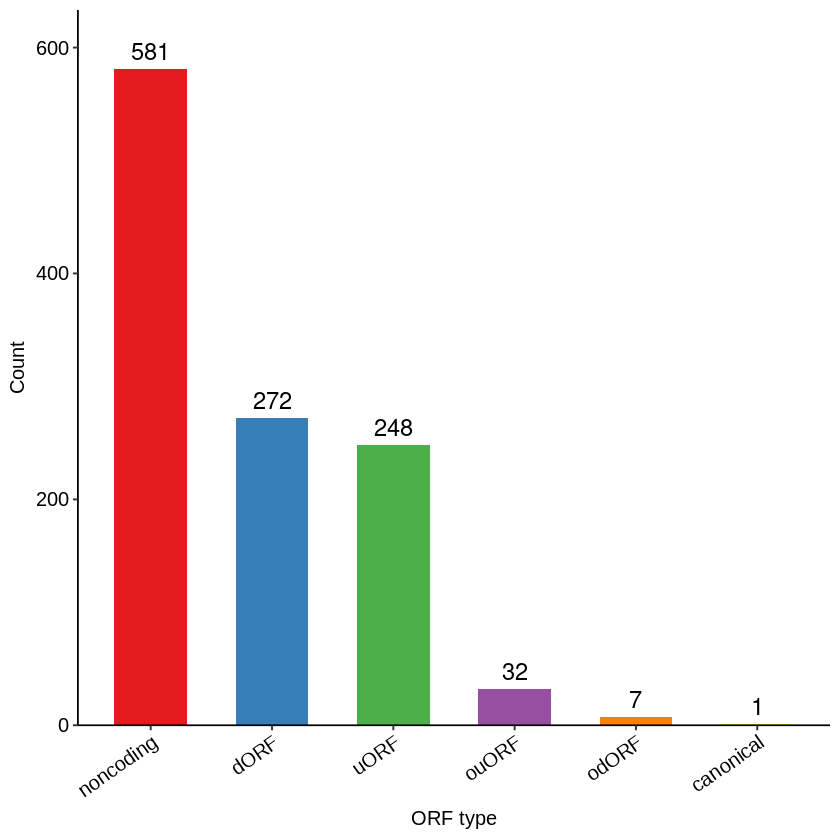

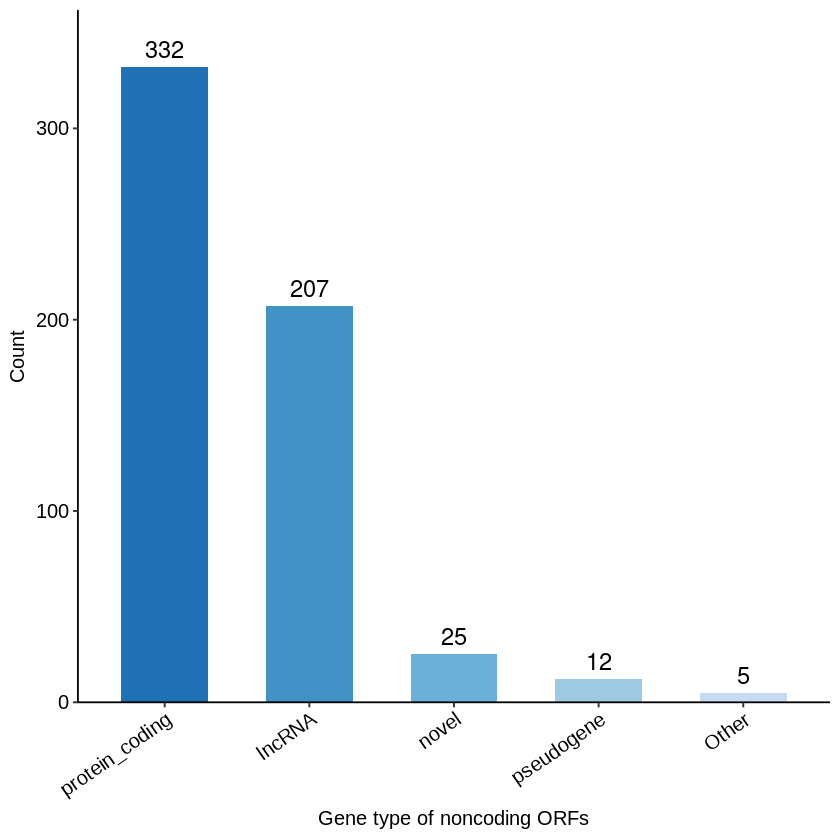

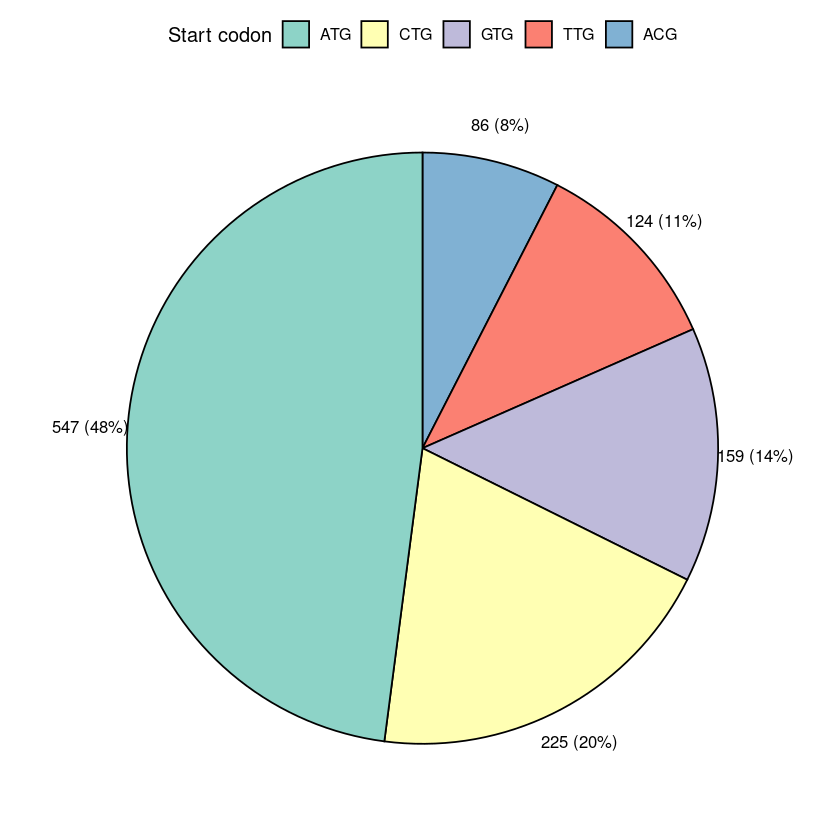

In [18]:
output_path <- "/home/user/data3/lit/project/sORFs/11-denovo-list/figures"
denovo_orfs_all -> df
## 不同的ORF类型
df %>% count(ORF_type) %>% arrange(desc(n)) -> df_type_n
df_type_n$ORF_type <- factor(df_type_n$ORF_type,levels = df_type_n$ORF_type)
df_type_n %>%  bar_plot_basic(., "ORF_type","n",fil_col = "ORF_type",label = T)+
guides(fill="none")+labs(x="ORF type",y="Count")+
theme(axis.text.x = element_text(angle=35,vjust = 1,hjust = 1))-> p1
p1
ggsave(p1,filename = o("ORF_type.pdf"),height = 5,width = 5)

filter(df, ORF_type == "noncoding") %>% 
  mutate(Gene_type_1 = case_when(
    grepl("pseudogene", Gene_type) ~ "pseudogene",
    Gene_type %in% c("Mt_rRNA", "TEC", "artifact", "misc_RNA") ~ "Other",
    TRUE ~ Gene_type
  )) %>% 
  count(Gene_type_1) %>% 
arrange(desc(n)) %>% 
mutate(Gene_type_1=factor(Gene_type_1,levels=Gene_type_1)) %>% 
bar_plot_basic(., "Gene_type_1","n",fil_col = "Gene_type_1",label = T)+
scale_fill_manual(values = rev(brewer.pal(name = "Blues",n=9)[3:7]))+
labs(x="Gene type of noncoding ORFs",y="Count")+
theme_3(rotate = T)+
guides(fill="none")->p2
p2
ggsave(p2,filename = o("noncodoing.orf.gene.type.pdf"),height = 5,width = 5)

## start codon
df %>% count(Start_codon) %>% arrange(desc(n)) -> df_1
df$Start_codon <- factor(df$Start_codon,levels = df_1$Start_codon)
pie_plot(df,"Start_codon") + labs(fill="Start codon") -> p3
p3
ggsave(p3,filename = o("scodon_type.pdf"),height = 5,width = 5)

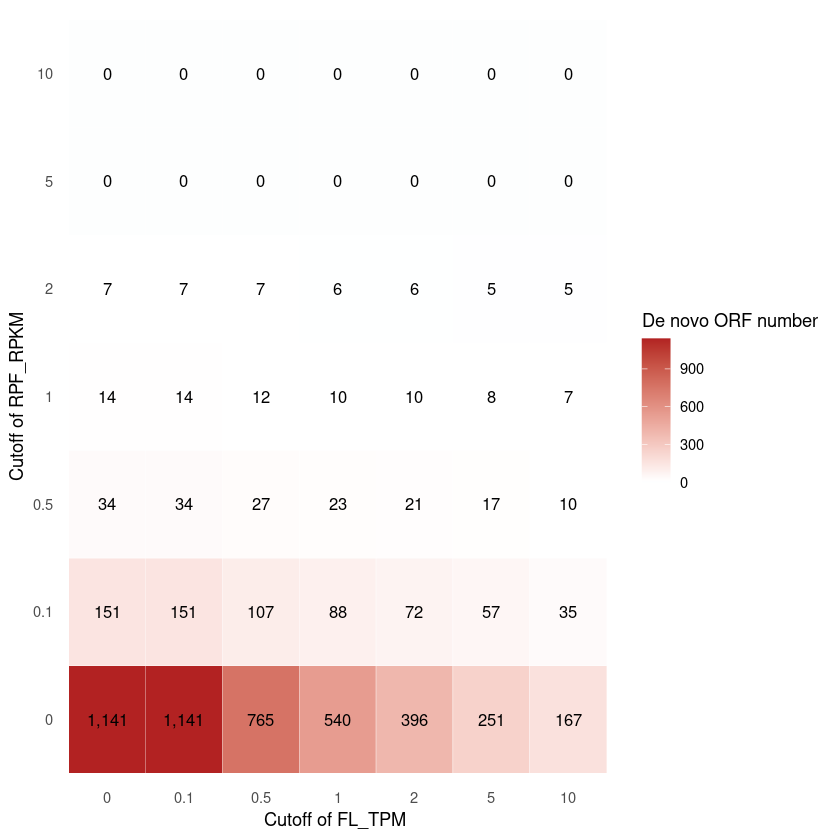

In [25]:
# library(tidyverse)

# 定义阈值
thresholds <- c(0,0.1, 0.5, 1, 2, 5, 10)

# 计算每个阈值组合下的ORF数量
count_orfs <- expand.grid(
  FL_TPM_thresh = thresholds,
  RPF_RPKM_thresh = thresholds
) %>%
  rowwise() %>%
  mutate(
    n_orfs = sum(df$FL_TPM >= FL_TPM_thresh & df$RPF_RPKM >= RPF_RPKM_thresh)
  ) %>%
  ungroup()

# 热图
ggplot(count_orfs, aes(x = factor(FL_TPM_thresh), 
                        y = factor(RPF_RPKM_thresh), 
                        fill = n_orfs)) +
  geom_tile(color = "white") +
  geom_text(aes(label = scales::comma(n_orfs)), size = 3.5) +
  scale_fill_gradient2(low = "steelblue", mid = "white", high = "firebrick",
                       midpoint = median(count_orfs$n_orfs),
                       name = "De novo ORF number") +
  labs(x = "Cutoff of FL_TPM ", y = "Cutoff of RPF_RPKM") +
  theme_minimal() +
  theme(panel.grid = element_blank())